In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-05-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_0

In [28]:
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
# from keras.utils import np_utils, to_categorical
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, History

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [30]:
Ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
Tess = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"

In [31]:
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/a...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...


In [32]:
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()


,Emotions,Path
0,fear,/kaggle/input/toronto-emotional-speech-set-tes...
1,fear,/kaggle/input/toronto-emotional-speech-set-tes...
2,fear,/kaggle/input/toronto-emotional-speech-set-tes...
3,fear,/kaggle/input/toronto-emotional-speech-set-tes...
4,fear,/kaggle/input/toronto-emotional-speech-set-tes...


In [33]:
data_path = pd.concat([Ravdess_df,Tess_df], axis = 0)


data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/a...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...


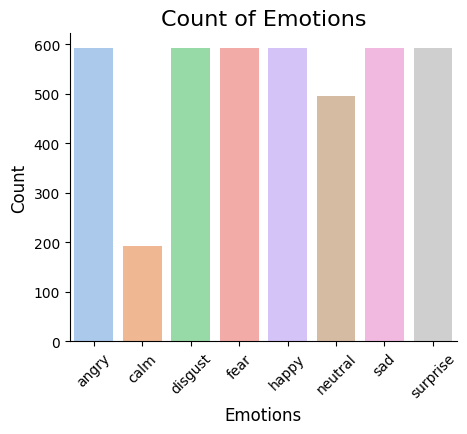

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure that Emotions is treated as a categorical variable
data_path['Emotions'] = data_path['Emotions'].astype('category')

# Set the pastel color palette
pastel_colors = sns.color_palette("pastel", len(data_path.Emotions.cat.categories))

# Create the count plot
plt.figure(figsize=(5, 4))  # Optional: Set figure size
plt.title('Count of Emotions', size=16)
sns.countplot(x='Emotions', data=data_path, palette=pastel_colors)  # Use x='Emotions'
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.xticks(rotation=45)  # Optional: Rotate x-axis labels for better readability
plt.show()


In [36]:
# def create_waveplot(data, sr, e):
#     plt.figure(figsize=(10, 3))
#     plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
#     librosa.display.waveshow(data, sr=sr)
#     plt.show()

def create_waveplot(data, sr, e, alpha=0.5):
    plt.figure(figsize=(5,3))  #(10,3)
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveshow(data, sr=sr, alpha=alpha)
    plt.show()

def create_spectrogram(data, sr, e):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(5, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    plt.colorbar()

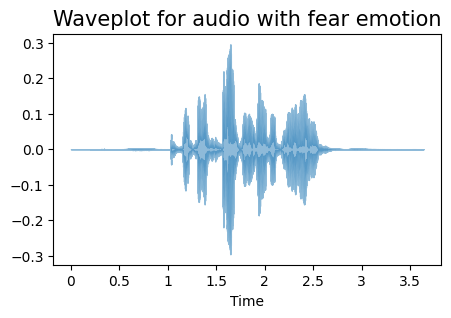

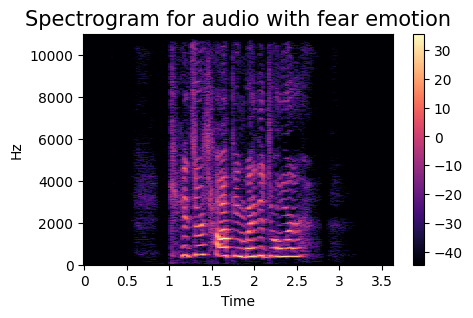

In [37]:
# import librosa
# import librosa.display
# import matplotlib.pyplot as plt

# # Load your audio file
# # audio_path = 'path_to_your_audio_file.wav'  # Update this with your audio file path
# emotion = "fear"
# audio_path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
# y, sr = librosa.load(audio_path)

# # Create a new figure
# plt.figure(figsize=(14, 5))

# # Plot the waveform
# # librosa.display.waveshow(y, sr=sr, alpha=0.5)  # use waveshow instead of waveplot in newer versions
# create_waveplot(y, sr=sr, alpha=0.5)

# plt.title('Waveform')
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.show()

import librosa
import librosa.display
import matplotlib.pyplot as plt

# Define the emotion you want to visualize
emotion = "fear"

# Select an audio file path based on the emotion
audio_path = np.array(data_path.Path[data_path.Emotions == emotion])[1]

# Load the audio data
y, sr = librosa.load(audio_path)

# Plot the waveform using the create_waveplot function
create_waveplot(y, sr, emotion)

create_spectrogram(y, sr, emotion)

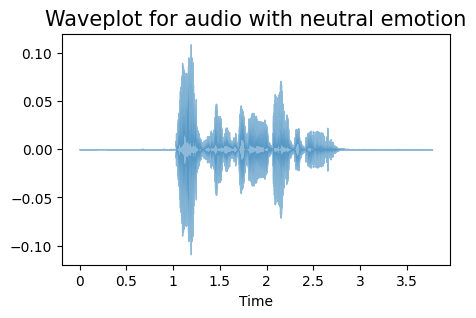

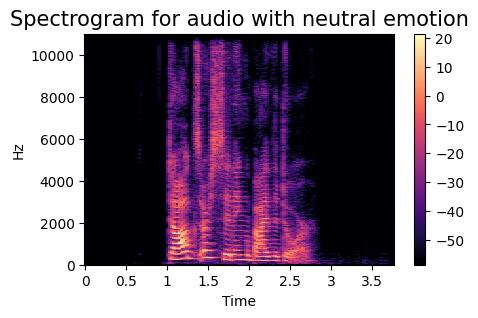

In [38]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Define the emotion you want to visualize
emotion = "neutral"

# Select an audio file path based on the emotion
audio_path = np.array(data_path.Path[data_path.Emotions == emotion])[1]

# Load the audio data
y, sr = librosa.load(audio_path)

# Plot the waveform using the create_waveplot function
create_waveplot(y, sr, emotion)

create_spectrogram(y, sr, emotion)

In [39]:
import numpy as np
import pandas as pd
import librosa

def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

# Changed the definition of the stretch function to remove 'self'
def stretch(data):
    # Rate is now used for the time_stretch function directly
    return librosa.effects.time_stretch(data, rate = 0.8)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sample_rate, pitch_factor=0.7):
    n_steps = int(pitch_factor * 12)  # Convert pitch factor to half-steps
    return librosa.effects.pitch_shift(data, sr=sample_rate, n_steps=n_steps)

def extract_features(data, sample_rate):
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))

    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft))

    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc))

    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))

    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel))

    return result

def get_features(path):
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)  # Load audio file

    res1 = extract_features(data, sample_rate)  # Extract features for original audio
    result = np.array(res1)

    noise_data = noise(data)  # Add noise
    res2 = extract_features(noise_data, sample_rate)  # Extract features for noisy audio
    result = np.vstack((result, res2))

    new_data = stretch(data)  # Time-stretch audio
    data_stretch_pitch = pitch(new_data, sample_rate)  # Shift pitch
    res3 = extract_features(data_stretch_pitch, sample_rate)  # Extract features for modified audio
    result = np.vstack((result, res3))

    return result

saved_features_filepath = "/kaggle/input/speech-emotion-recognition-output-checkpoint-1/features.csv"
if os.path.exists(saved_features_filepath):
    Features = pd.read_csv(saved_features_filepath)
else:
    X, Y = [], []
    for path, emotion in zip(data_path.Path, data_path.Emotions):
        feature = get_features(path)  # Call get_features with the audio path
        for ele in feature:
            X.append(ele)
            Y.append(emotion)

    Features = pd.DataFrame(X)
    Features['labels'] = Y
    Features.to_csv('features.csv', index=False)

print(Features.shape)


(12720, 163)


In [40]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [41]:
# Load the features and labels
X = Features.drop(columns=['labels'])
y = Features['labels']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8904, 162)
X_test shape: (3816, 162)


In [42]:
# Define the function to evaluate each model
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()


In [ ]:
svm_classifier = SVC()

# Define parameter grid for grid search
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Make predictions using the best estimator
svm_predictions = grid_search.best_estimator_.predict(X_test)

# Evaluate the SVM model
evaluate_model(y_test, svm_predictions, "Support Vector Machine")

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [ ]:
import pandas as pd

# Create a DataFrame with actual and predicted labels
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_SVM': svm_predictions,
    # 'Predicted_NaiveBayes': y_pred_nb,
    # 'Predicted_RandomForest': y_pred_rf,
    # 'Predicted_DecisionTree': y_pred_dt
})

# Display a sample of the actual vs predicted labels for SVM (first 20 samples)
print("Actual vs Predicted Labels (Sample):")
print(results_df[['Actual', 'Predicted_SVM']].head(20))

DT

--- Decision Tree Classifier ---
Accuracy: 0.5529350104821803
F1 Score: 0.5680817864857998
Precision: 0.6438026693545102
Recall: 0.5529350104821803

Classification Report:
               precision    recall  f1-score   support

       angry       0.59      0.46      0.52       555
        calm       0.40      0.53      0.46       159
     disgust       0.32      0.77      0.45       534
        fear       0.76      0.63      0.69       543
       happy       0.70      0.36      0.48       551
     neutral       0.91      0.71      0.80       429
         sad       0.89      0.54      0.67       503
    surprise       0.47      0.45      0.46       542

    accuracy                           0.55      3816
   macro avg       0.63      0.56      0.57      3816
weighted avg       0.64      0.55      0.57      3816



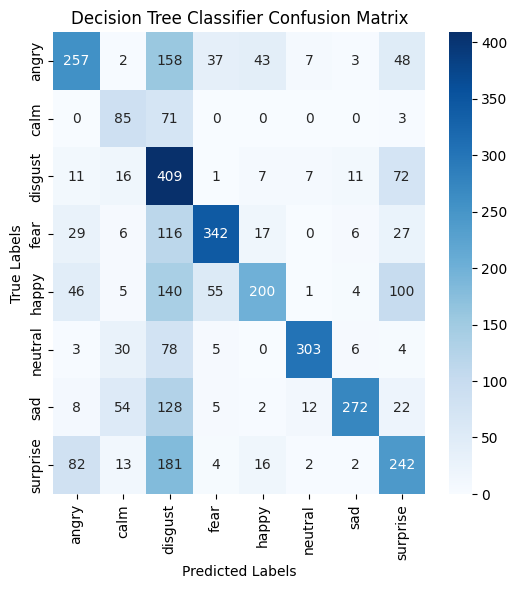

In [43]:
dt_classifier = DecisionTreeClassifier(max_depth=6, random_state=42)

# Fit the classifier with training data
dt_classifier.fit(X_train, y_train)

# Make predictions
dt_predictions = dt_classifier.predict(X_test)

# Evaluate the Decision Tree model
evaluate_model(y_test, dt_predictions, "Decision Tree Classifier")

In [44]:
import pandas as pd

# Create a DataFrame with actual and predicted labels
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_DT': dt_predictions,
    # 'Predicted_NaiveBayes': y_pred_nb,
    # 'Predicted_RandomForest': y_pred_rf,
    # 'Predicted_DecisionTree': y_pred_dt
})

# Display a sample of the actual vs predicted labels for SVM (first 20 samples)
print("Actual vs Predicted Labels (Sample):")
print(results_df[['Actual', 'Predicted_DT']].head(20))

Actual vs Predicted Labels (Sample):
         Actual Predicted_DT
6699    disgust     surprise
9355    neutral      neutral
937         sad      disgust
8832    disgust      disgust
2124      happy        angry
1457      angry     surprise
6496    disgust      disgust
8813    disgust      disgust
290        calm         calm
9850   surprise        happy
3088       calm      disgust
11687       sad          sad
3817       calm      disgust
6757    neutral      neutral
4233      happy      disgust
11022     happy        happy
5412      angry        angry
10265  surprise     surprise
9238    neutral         fear
8940    disgust      disgust


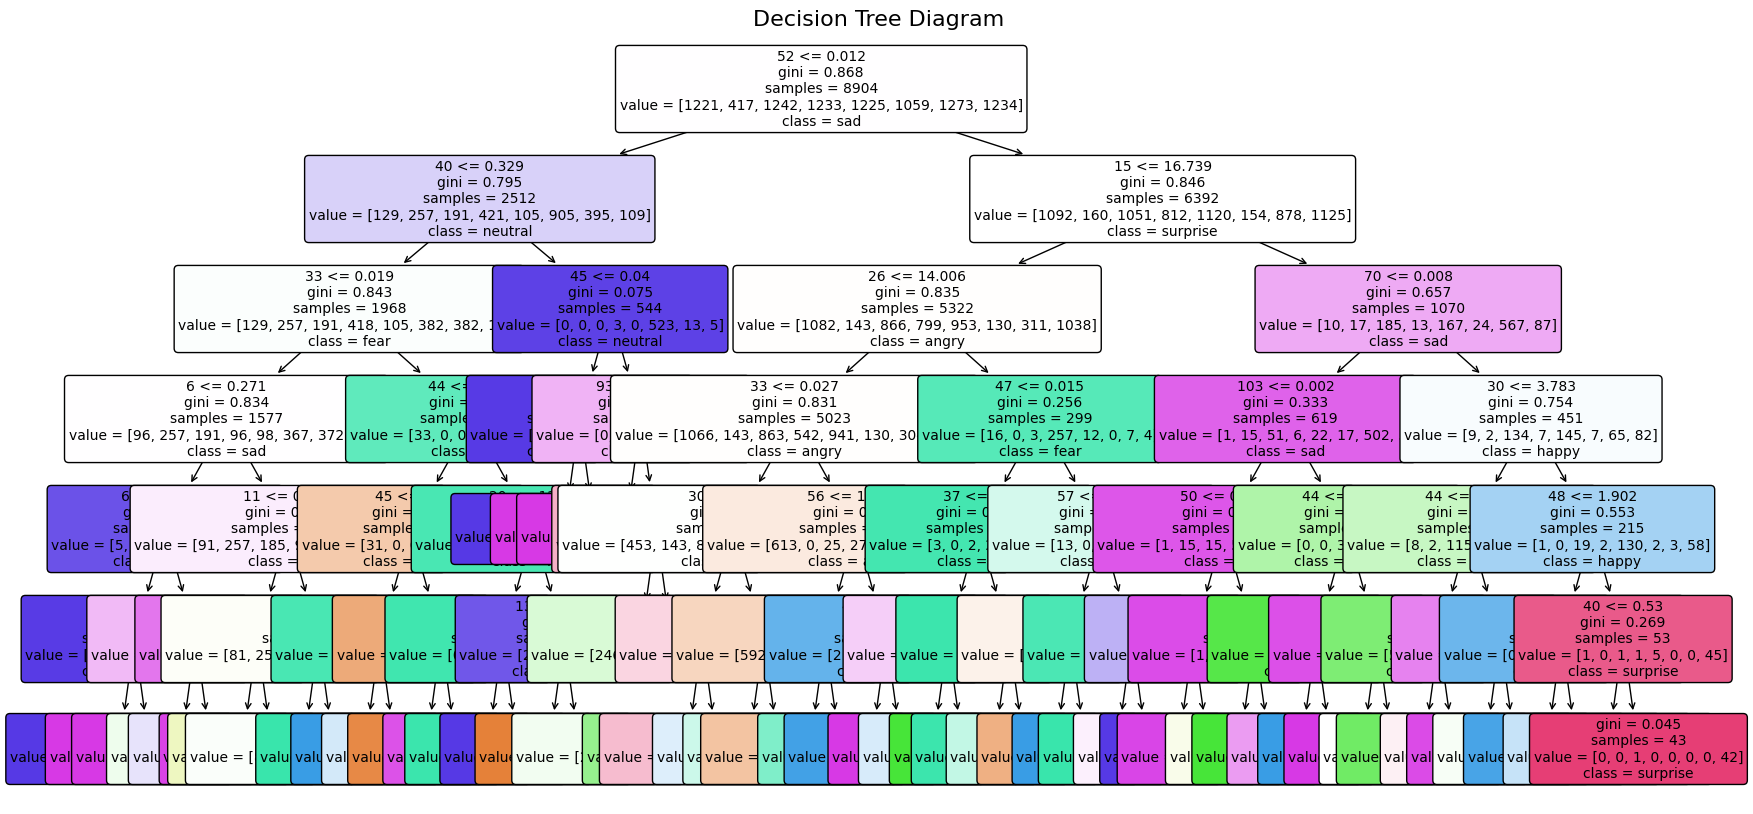

In [45]:
plt.figure(figsize=(20, 10))  # Set the figure size
plot_tree(
    dt_classifier, 
    feature_names=X_train.columns if hasattr(X_train, 'columns') else None,  # Feature names if available
    class_names=dt_classifier.classes_.astype(str),  # Class names
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Diagram", fontsize=16)
plt.show()

rf

--- Random Forest Classifier ---
Accuracy: 0.8377882599580713
F1 Score: 0.839569837566611
Precision: 0.8468566124128155
Recall: 0.8377882599580713

Classification Report:
               precision    recall  f1-score   support

       angry       0.87      0.89      0.88       555
        calm       0.58      0.89      0.70       159
     disgust       0.74      0.84      0.79       534
        fear       0.91      0.85      0.88       543
       happy       0.86      0.74      0.80       551
     neutral       0.93      0.90      0.91       429
         sad       0.87      0.83      0.85       503
    surprise       0.85      0.81      0.83       542

    accuracy                           0.84      3816
   macro avg       0.83      0.84      0.83      3816
weighted avg       0.85      0.84      0.84      3816



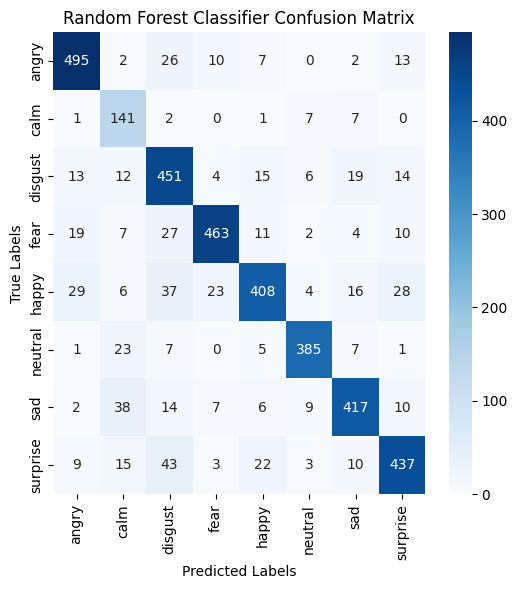

In [46]:
rf_classifier = RandomForestClassifier(n_estimators=20, random_state=42)

# Fit the classifier with training data
rf_classifier.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_classifier.predict(X_test)

# Evaluate the Random Forest model
evaluate_model(y_test, rf_predictions, "Random Forest Classifier")

In [47]:
import pandas as pd

# Create a DataFrame with actual and predicted labels
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_RF': rf_predictions,
    # 'Predicted_NaiveBayes': y_pred_nb,
    # 'Predicted_RandomForest': y_pred_rf,
    # 'Predicted_DecisionTree': y_pred_dt
})

# Display a sample of the actual vs predicted labels for SVM (first 20 samples)
print("Actual vs Predicted Labels (Sample):")
print(results_df[['Actual', 'Predicted_RF']].head(20))

Actual vs Predicted Labels (Sample):
         Actual Predicted_RF
6699    disgust      disgust
9355    neutral      neutral
937         sad          sad
8832    disgust      disgust
2124      happy        happy
1457      angry        happy
6496    disgust      disgust
8813    disgust      disgust
290        calm      neutral
9850   surprise     surprise
3088       calm         calm
11687       sad          sad
3817       calm         calm
6757    neutral      neutral
4233      happy        happy
11022     happy        happy
5412      angry        angry
10265  surprise          sad
9238    neutral      neutral
8940    disgust      disgust


nb

--- Naive Bayes Classifier ---
Accuracy: 0.40146750524109015
F1 Score: 0.40687789940677427
Precision: 0.499991696193174
Recall: 0.40146750524109015

Classification Report:
               precision    recall  f1-score   support

       angry       0.62      0.23      0.33       555
        calm       0.18      0.97      0.30       159
     disgust       0.37      0.49      0.42       534
        fear       0.74      0.29      0.42       543
       happy       0.40      0.30      0.35       551
     neutral       0.72      0.55      0.63       429
         sad       0.41      0.55      0.47       503
    surprise       0.36      0.28      0.31       542

    accuracy                           0.40      3816
   macro avg       0.48      0.46      0.40      3816
weighted avg       0.50      0.40      0.41      3816



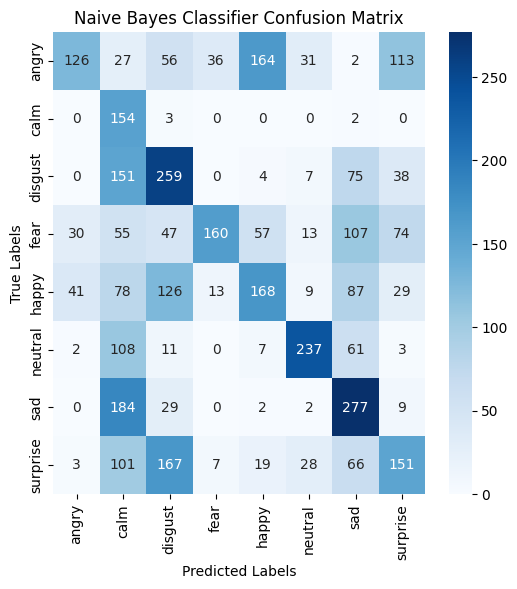

In [48]:
# Define the Naive Bayes classifier
nb_classifier = GaussianNB()

# Fit the classifier with training data
nb_classifier.fit(X_train, y_train)

# Make predictions
nb_predictions = nb_classifier.predict(X_test)

# Evaluate the Naive Bayes model
evaluate_model(y_test, nb_predictions, "Naive Bayes Classifier")

In [49]:
import pandas as pd

# Create a DataFrame with actual and predicted labels
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_NB': nb_predictions,
    # 'Predicted_NaiveBayes': y_pred_nb,
    # 'Predicted_RandomForest': y_pred_rf,
    # 'Predicted_DecisionTree': y_pred_dt
})

# Display a sample of the actual vs predicted labels for SVM (first 20 samples)
print("Actual vs Predicted Labels (Sample):")
print(results_df[['Actual', 'Predicted_NB']].head(20))

Actual vs Predicted Labels (Sample):
         Actual Predicted_NB
6699    disgust      disgust
9355    neutral          sad
937         sad         calm
8832    disgust        happy
2124      happy        happy
1457      angry         calm
6496    disgust      disgust
8813    disgust         calm
290        calm         calm
9850   surprise          sad
3088       calm         calm
11687       sad          sad
3817       calm         calm
6757    neutral          sad
4233      happy      disgust
11022     happy      disgust
5412      angry        happy
10265  surprise          sad
9238    neutral      neutral
8940    disgust          sad


In [2]:
from sklearn.svm import SVC
svm_classifier = SVC()

# Fit the SVM model to the training data
svm_classifier.fit(X_train, y_train)

# Make predictions
svm_predictions = svm_classifier.predict(X_test)

# Evaluate the SVM model
evaluate_model(y_test, svm_predictions, "Support Vector Machine")

NameError: name 'X_train' is not defined

In [3]:
print("Hi")

Hi


In [ ]:
import pandas as pd

# Create a DataFrame with actual and predicted labels
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_SVM': svm_predictions,
    # 'Predicted_NaiveBayes': y_pred_nb,
    # 'Predicted_RandomForest': y_pred_rf,
    # 'Predicted_DecisionTree': y_pred_dt
})

# Display a sample of the actual vs predicted labels for SVM (first 20 samples)
print("Actual vs Predicted Labels (Sample):")
print(results_df[['Actual', 'Predicted_SVM']].head(20))

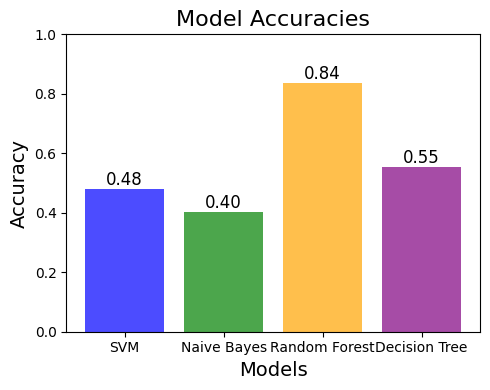

In [14]:
import matplotlib.pyplot as plt

# Model names
models = ['SVM', 'Naive Bayes', 'Random Forest', 'Decision Tree']

# Corresponding accuracy scores
accuracies = [0.4801, 0.4015, 0.8378, 0.5529]

# Plot the bar chart
plt.figure(figsize=(5, 4))
bars = plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'purple'], alpha=0.7)

# Add accuracy values on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{acc:.2f}", 
             ha='center', va='bottom', fontsize=12, color='black')

# Add labels and title
plt.title('Model Accuracies', fontsize=16)
plt.xlabel('Models', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)  # Set y-axis limit to 0-1 as accuracies are percentages
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


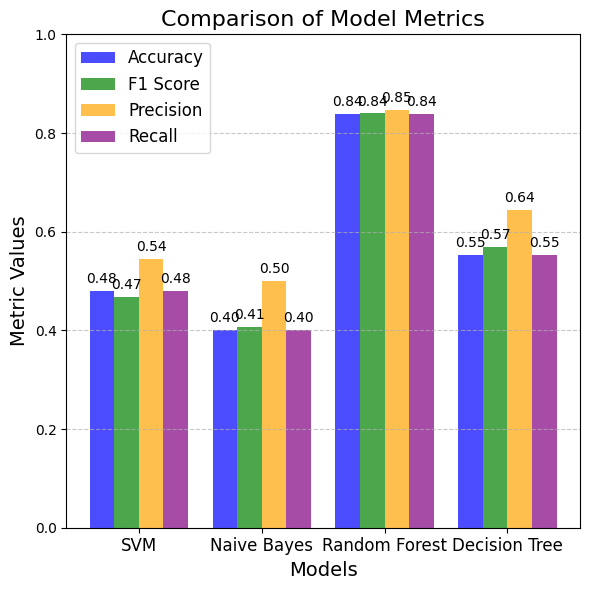

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['SVM', 'Naive Bayes', 'Random Forest', 'Decision Tree']

# Metric values for each model
accuracy = [0.4801, 0.4015, 0.8378, 0.5529]
f1_score = [0.4684, 0.4069, 0.8396, 0.5681]
precision = [0.5448, 0.5000, 0.8469, 0.6438]
recall = [0.4801, 0.4015, 0.8378, 0.5529]

# Grouped bar chart settings
x = np.arange(len(models))  # X-axis positions for models
bar_width = 0.2  # Width of each bar

# Create the figure and axes
plt.figure(figsize=(6, 6))

# Plot each metric as a separate bar group
plt.bar(x - 1.5 * bar_width, accuracy, width=bar_width, label='Accuracy', color='blue', alpha=0.7)
plt.bar(x - 0.5 * bar_width, f1_score, width=bar_width, label='F1 Score', color='green', alpha=0.7)
plt.bar(x + 0.5 * bar_width, precision, width=bar_width, label='Precision', color='orange', alpha=0.7)
plt.bar(x + 1.5 * bar_width, recall, width=bar_width, label='Recall', color='purple', alpha=0.7)

# Add values on top of bars
metrics = [accuracy, f1_score, precision, recall]
for metric_index, metric in enumerate(metrics):
    for i, value in enumerate(metric):
        plt.text(x[i] - 1.5 * bar_width + metric_index * bar_width, value + 0.01, f"{value:.2f}", 
                 ha='center', va='bottom', fontsize=10, color='black')

# Add labels, title, and legend
plt.xlabel('Models', fontsize=14)
plt.ylabel('Metric Values', fontsize=14)
plt.title('Comparison of Model Metrics', fontsize=16)
plt.xticks(x, models, fontsize=12)
plt.ylim(0, 1)  # Metrics are scaled between 0 and 1
plt.legend(loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


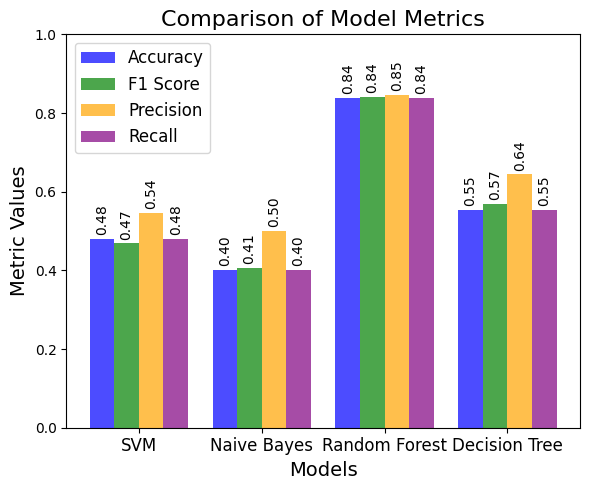

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['SVM', 'Naive Bayes', 'Random Forest', 'Decision Tree']

# Metric values for each model
accuracy = [0.4801, 0.4015, 0.8378, 0.5529]
f1_score = [0.4684, 0.4069, 0.8396, 0.5681]
precision = [0.5448, 0.5000, 0.8469, 0.6438]
recall = [0.4801, 0.4015, 0.8378, 0.5529]

# Grouped bar chart settings
x = np.arange(len(models))  # X-axis positions for models
bar_width = 0.2  # Width of each bar

# Create the figure and axes
plt.figure(figsize=(6, 5))

# Plot each metric as a separate bar group
plt.bar(x - 1.5 * bar_width, accuracy, width=bar_width, label='Accuracy', color='blue', alpha=0.7)
plt.bar(x - 0.5 * bar_width, f1_score, width=bar_width, label='F1 Score', color='green', alpha=0.7)
plt.bar(x + 0.5 * bar_width, precision, width=bar_width, label='Precision', color='orange', alpha=0.7)
plt.bar(x + 1.5 * bar_width, recall, width=bar_width, label='Recall', color='purple', alpha=0.7)

# Add rotated values on top of bars
metrics = [accuracy, f1_score, precision, recall]
for metric_index, metric in enumerate(metrics):
    for i, value in enumerate(metric):
        plt.text(x[i] - 1.5 * bar_width + metric_index * bar_width, value + 0.01, 
                 f"{value:.2f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)

# Add labels, title, and legend
plt.xlabel('Models', fontsize=14)
plt.ylabel('Metric Values', fontsize=14)
plt.title('Comparison of Model Metrics', fontsize=16)
plt.xticks(x, models, fontsize=12)
plt.ylim(0, 1)  # Metrics are scaled between 0 and 1
plt.legend(loc='upper left', fontsize=12)

plt.tight_layout()

# Show the plot
plt.show()


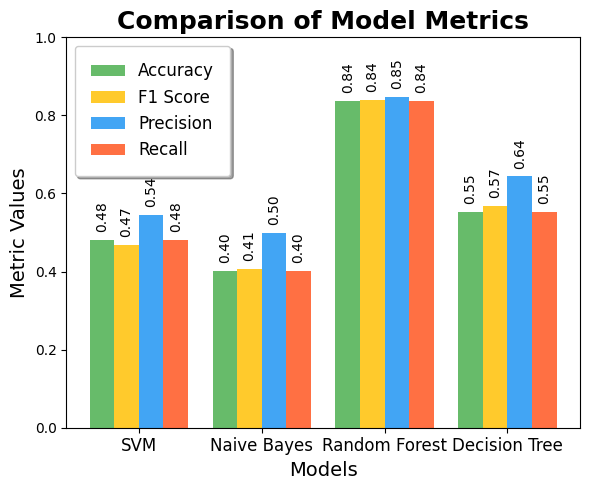

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['SVM', 'Naive Bayes', 'Random Forest', 'Decision Tree']

# Metric values for each model
accuracy = [0.4801, 0.4015, 0.8378, 0.5529]
f1_score = [0.4684, 0.4069, 0.8396, 0.5681]
precision = [0.5448, 0.5000, 0.8469, 0.6438]
recall = [0.4801, 0.4015, 0.8378, 0.5529]

# Grouped bar chart settings
x = np.arange(len(models))  # X-axis positions for models
bar_width = 0.2  # Width of each bar

# Define visually pleasing colors
colors = ['#4CAF50', '#FFC107', '#2196F3', '#FF5722']  # Green, Amber, Blue, Orange

# Create the figure and axes
plt.figure(figsize=(6, 5))

# Plot each metric as a separate bar group
plt.bar(x - 1.5 * bar_width, accuracy, width=bar_width, label='Accuracy', color=colors[0], alpha=0.85)
plt.bar(x - 0.5 * bar_width, f1_score, width=bar_width, label='F1 Score', color=colors[1], alpha=0.85)
plt.bar(x + 0.5 * bar_width, precision, width=bar_width, label='Precision', color=colors[2], alpha=0.85)
plt.bar(x + 1.5 * bar_width, recall, width=bar_width, label='Recall', color=colors[3], alpha=0.85)

# Add rotated values on top of bars
metrics = [accuracy, f1_score, precision, recall]
for metric_index, metric in enumerate(metrics):
    for i, value in enumerate(metric):
        plt.text(x[i] - 1.5 * bar_width + metric_index * bar_width, value + 0.02, 
                 f"{value:.2f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)

# Add labels, title, and legend
plt.xlabel('Models', fontsize=14)
plt.ylabel('Metric Values', fontsize=14)
plt.title('Comparison of Model Metrics', fontsize=18, fontweight='bold')
plt.xticks(x, models, fontsize=12)
plt.ylim(0, 1)  # Metrics are scaled between 0 and 1
plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True, borderpad=1)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()
